# ThetreStageAI — Figure 7 from the Real Dataset and Codebase

This notebook generates **paper-ready Figure 7 candidates directly from the project files**.  
It does **not hard-code experimental accuracy/precision/recall** and does not invent results.

It reads:

- `Bangla_Natok_500_MultiView_RAG_Dataset/...`
- `db.sqlite3` through the Django ORM
- `GenerationRun` records from the `theatre` app

Outputs are saved under:

```text
Notebooks/eda_outputs/figures/
Notebooks/eda_outputs/tables/
```

Recommended paper use:

- **Dataset composition figure** — safe to use if derived counts are verified.
- **Generation-run figure** — use only if the database contains controlled experiment runs, not ad-hoc development/debug runs.


## 1. Imports and project-root detection

In [1]:
from pathlib import Path
import os
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "manage.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find project root. Open this notebook from inside ThetreStageAI "
        "or set PROJECT_ROOT manually."
    )

PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / "Notebooks"
FIG_DIR = NOTEBOOK_DIR / "eda_outputs" / "figures"
TABLE_DIR = NOTEBOOK_DIR / "eda_outputs" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figure dir :", FIG_DIR)
print("Table dir  :", TABLE_DIR)


Project root: /home/mehedinaeem/Desktop/Code/ThetreStageAI
Figure dir : /home/mehedinaeem/Desktop/Code/ThetreStageAI/Notebooks/eda_outputs/figures
Table dir  : /home/mehedinaeem/Desktop/Code/ThetreStageAI/Notebooks/eda_outputs/tables


## 2. Locate the real theatre dataset

In [2]:
DATASET_ROOT_CANDIDATES = [
    PROJECT_ROOT / "Bangla_Natok_500_MultiView_RAG_Dataset" / "bangla_natok_500",
    PROJECT_ROOT / "Bangla_Natok_500_MultiView_RAG_Dataset",
    PROJECT_ROOT / "data" / "bangla_natok_500",
]

def find_dataset_root() -> Path:
    for root in DATASET_ROOT_CANDIDATES:
        if (root / "bangla_natok_500.jsonl").exists():
            return root
        nested = root / "bangla_natok_500"
        if (nested / "bangla_natok_500.jsonl").exists():
            return nested
    raise FileNotFoundError(
        "Could not locate bangla_natok_500.jsonl. "
        "Update DATASET_ROOT_CANDIDATES to match your project."
    )

DATASET_ROOT = find_dataset_root()

MAIN_JSONL = DATASET_ROOT / "bangla_natok_500.jsonl"
SCENE_JSONL = DATASET_ROOT / "retrieval_views" / "scene_view.jsonl"
BLOCKING_JSONL = DATASET_ROOT / "retrieval_views" / "blocking_view.jsonl"
LIGHTING_JSONL = DATASET_ROOT / "retrieval_views" / "lighting_view.jsonl"
ALL_VIEWS_JSONL = DATASET_ROOT / "retrieval_views" / "all_retrieval_views.jsonl"

for p in [MAIN_JSONL, SCENE_JSONL, BLOCKING_JSONL, LIGHTING_JSONL, ALL_VIEWS_JSONL]:
    print(("OK " if p.exists() else "MISSING "), p)


OK  /home/mehedinaeem/Desktop/Code/ThetreStageAI/Bangla_Natok_500_MultiView_RAG_Dataset/bangla_natok_500/bangla_natok_500.jsonl
OK  /home/mehedinaeem/Desktop/Code/ThetreStageAI/Bangla_Natok_500_MultiView_RAG_Dataset/bangla_natok_500/retrieval_views/scene_view.jsonl
OK  /home/mehedinaeem/Desktop/Code/ThetreStageAI/Bangla_Natok_500_MultiView_RAG_Dataset/bangla_natok_500/retrieval_views/blocking_view.jsonl
OK  /home/mehedinaeem/Desktop/Code/ThetreStageAI/Bangla_Natok_500_MultiView_RAG_Dataset/bangla_natok_500/retrieval_views/lighting_view.jsonl
OK  /home/mehedinaeem/Desktop/Code/ThetreStageAI/Bangla_Natok_500_MultiView_RAG_Dataset/bangla_natok_500/retrieval_views/all_retrieval_views.jsonl


## 3. Load JSONL files

In [3]:
def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} at line {line_no}") from exc
    return rows

records = read_jsonl(MAIN_JSONL)
scene_docs = read_jsonl(SCENE_JSONL)
blocking_docs = read_jsonl(BLOCKING_JSONL)
lighting_docs = read_jsonl(LIGHTING_JSONL)
all_view_docs = read_jsonl(ALL_VIEWS_JSONL)

print("Theatre records             :", len(records))
print("Scene retrieval documents   :", len(scene_docs))
print("Blocking retrieval documents:", len(blocking_docs))
print("Lighting retrieval documents:", len(lighting_docs))
print("All retrieval documents      :", len(all_view_docs))


Theatre records             : 500
Scene retrieval documents   : 500
Blocking retrieval documents: 500
Lighting retrieval documents: 500
All retrieval documents      : 1500


## 4. Compute all dataset statistics from the files

In [4]:
dataset_stats = {
    "Theatre records": len(records),
    "Scene retrieval documents": len(scene_docs),
    "Blocking retrieval documents": len(blocking_docs),
    "Lighting retrieval documents": len(lighting_docs),
    "Total retrieval documents": len(all_view_docs),
    "Dialogue lines": sum(len(r.get("dialogue", [])) for r in records),
    "Blocking cues": sum(len(r.get("blocking", [])) for r in records),
    "Lighting cues": sum(len(r.get("lighting", [])) for r in records),
    "Sound cues": sum(len(r.get("sound", [])) for r in records),
}

dataset_stats_df = (
    pd.DataFrame(dataset_stats.items(), columns=["Statistic", "Count"])
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

display(dataset_stats_df)
dataset_stats_df.to_csv(TABLE_DIR / "figure7_dataset_statistics.csv", index=False)

print("\nSaved:", TABLE_DIR / "figure7_dataset_statistics.csv")


,Statistic,Count
0,Dialogue lines,3000
1,Total retrieval documents,1500
2,Sound cues,1000
3,Blocking cues,1000
4,Lighting cues,1000
5,Theatre records,500
6,Lighting retrieval documents,500
7,Scene retrieval documents,500
8,Blocking retrieval documents,500



Saved: /home/mehedinaeem/Desktop/Code/ThetreStageAI/Notebooks/eda_outputs/tables/figure7_dataset_statistics.csv


## 5. Integrity checks

In [5]:
source_ids = [r.get("id") for r in records]
scene_source_ids = [d.get("source_id") for d in scene_docs]
blocking_source_ids = [d.get("source_id") for d in blocking_docs]
lighting_source_ids = [d.get("source_id") for d in lighting_docs]

checks = pd.DataFrame([
    ["Main record IDs are unique", len(source_ids) == len(set(source_ids))],
    ["Scene docs cover all source records", set(scene_source_ids) == set(source_ids)],
    ["Blocking docs cover all source records", set(blocking_source_ids) == set(source_ids)],
    ["Lighting docs cover all source records", set(lighting_source_ids) == set(source_ids)],
    ["All-view count equals sum of three views",
     len(all_view_docs) == len(scene_docs) + len(blocking_docs) + len(lighting_docs)],
], columns=["Check", "Passed"])

display(checks)

if not checks["Passed"].all():
    raise AssertionError("One or more dataset integrity checks failed. Do not use the figure until fixed.")


,Check,Passed
0,Main record IDs are unique,True
1,Scene docs cover all source records,True
2,Blocking docs cover all source records,True
3,Lighting docs cover all source records,True
4,All-view count equals sum of three views,True


## 6. Paper-ready dataset composition figure

This is the safest Figure 7 if the paper needs a **dataset/result statistic figure**.  
It uses values computed directly from the files.


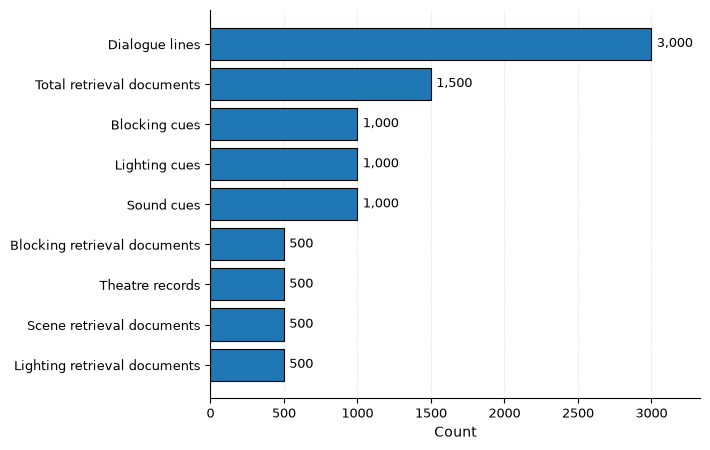

Saved PNG: /home/mehedinaeem/Desktop/Code/ThetreStageAI/Notebooks/eda_outputs/figures/figure7_dataset_statistics.png
Saved PDF: /home/mehedinaeem/Desktop/Code/ThetreStageAI/Notebooks/eda_outputs/figures/figure7_dataset_statistics.pdf


In [6]:
plot_df = dataset_stats_df.copy().sort_values("Count", ascending=True)

fig, ax = plt.subplots(figsize=(7.2, 4.6))

bars = ax.barh(
    plot_df["Statistic"],
    plot_df["Count"],
    edgecolor="black",
    linewidth=0.8
)

ax.set_xlabel("Count")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.35)
ax.set_axisbelow(True)

max_count = max(plot_df["Count"])
for bar, value in zip(bars, plot_df["Count"]):
    ax.text(
        bar.get_width() + max_count * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):,}",
        va="center",
        ha="left",
        fontsize=9,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=9)
ax.set_xlim(0, max_count * 1.11)

fig.tight_layout()

png_path = FIG_DIR / "figure7_dataset_statistics.png"
pdf_path = FIG_DIR / "figure7_dataset_statistics.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved PNG:", png_path)
print("Saved PDF:", pdf_path)


### Suggested IEEE caption

**Fig. 7. Statistical composition of the ThetreStageAI Bengali theatre dataset and its retrieval-specific documents.**


## 7. Optional retrieval-view figure

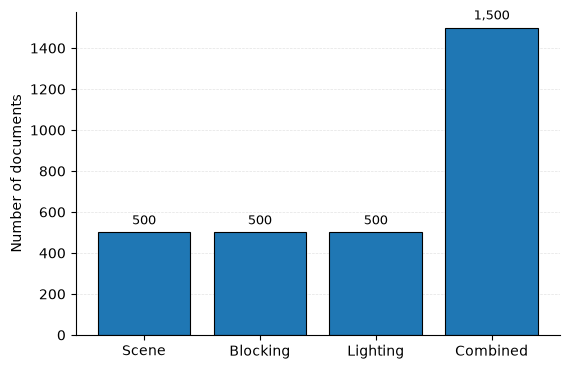

Saved: /home/mehedinaeem/Desktop/Code/ThetreStageAI/Notebooks/eda_outputs/figures/retrieval_view_document_counts.png
Saved: /home/mehedinaeem/Desktop/Code/ThetreStageAI/Notebooks/eda_outputs/figures/retrieval_view_document_counts.pdf


In [7]:
retrieval_stats = pd.DataFrame({
    "View": ["Scene", "Blocking", "Lighting", "Combined"],
    "Documents": [len(scene_docs), len(blocking_docs), len(lighting_docs), len(all_view_docs)],
})

fig, ax = plt.subplots(figsize=(5.8, 3.8))
bars = ax.bar(
    retrieval_stats["View"],
    retrieval_stats["Documents"],
    edgecolor="black",
    linewidth=0.8,
)

ax.set_ylabel("Number of documents")
ax.set_xlabel("")
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.35)
ax.set_axisbelow(True)

for bar, value in zip(bars, retrieval_stats["Documents"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 25,
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

png_path = FIG_DIR / "retrieval_view_document_counts.png"
pdf_path = FIG_DIR / "retrieval_view_document_counts.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:", png_path)
print("Saved:", pdf_path)


## 8. Load real GenerationRun records from the Django codebase

This reads actual rows from `db.sqlite3` through Django ORM.

**Do not use these as formal experimental results unless the runs were generated under a controlled evaluation protocol.**


In [8]:
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "thetrestageai.settings")

try:
    import django
    django.setup()

    from asgiref.sync import sync_to_async
    from theatre.models import GenerationRun

    run_fields = [
        "id",
        "project_id",
        "model_name",
        "model_settings",
        "rag_mode",
        "validated",
        "repair_attempts",
        "generation_time_seconds",
        "created_at",
    ]

    # IPython/Jupyter executes cells inside an asyncio event loop. Evaluate
    # Django's synchronous ORM in its thread-sensitive sync bridge instead
    # of disabling Django's async-safety protection globally.
    run_rows = await sync_to_async(
        lambda: list(GenerationRun.objects.all().values(*run_fields)),
        thread_sensitive=True,
    )()
    runs_df = pd.DataFrame(run_rows)

    print("GenerationRun rows:", len(runs_df))
    display(runs_df.tail())

except Exception as exc:
    runs_df = pd.DataFrame()
    print("Could not load GenerationRun data.")
    print(type(exc).__name__, str(exc))


GenerationRun rows: 7


,id,project_id,model_name,model_settings,rag_mode,validated,repair_attempts,generation_time_seconds,created_at
2,18,25,gemini-3.6-flash,"{'provider': 'gemini', 'model': 'gemini-3.6-flash', 'temperature': 0.2, 'max_output_tokens': 8192, 'timeout_seconds'...",full_multiview,True,0,40.901267,2026-09-05 03:11:37.890609+00:00
3,17,24,gemini-3.6-flash,"{'provider': 'gemini', 'model': 'gemini-3.6-flash', 'temperature': 0.2, 'max_output_tokens': 8192, 'timeout_seconds'...",full_multiview,True,0,29.947259,2026-08-27 18:16:45.925565+00:00
4,16,23,gemini-3.6-flash,"{'provider': 'gemini', 'model': 'gemini-3.6-flash', 'temperature': 0.2, 'max_output_tokens': 8192, 'timeout_seconds'...",full_multiview,True,0,20.846504,2026-08-27 17:39:12.899508+00:00
5,15,22,gemini-3.6-flash,"{'provider': 'gemini', 'model': 'gemini-3.6-flash', 'temperature': 0.2, 'max_output_tokens': 8192, 'timeout_seconds'...",full_multiview,True,0,31.162182,2026-08-27 17:38:23.454596+00:00
6,8,11,qwen3:4b,"{'provider': 'ollama', 'temperature': 0.2, 'think': False, 'timeout_seconds': 600}",full_multiview,True,0,249.947780,2026-08-27 02:29:54.656942+00:00


## 9. Summarize real generation runs

In [9]:
if not runs_df.empty:
    def provider_from_settings(value):
        if isinstance(value, dict):
            return value.get("provider", "unknown")
        return "unknown"

    runs_df["provider"] = runs_df["model_settings"].apply(provider_from_settings)

    summary = pd.DataFrame({
        "Metric": [
            "Total runs",
            "Validated runs",
            "Invalid runs",
            "Validation rate (%)",
            "Runs requiring repair",
            "Median generation time (s)",
        ],
        "Value": [
            len(runs_df),
            int(runs_df["validated"].sum()),
            int((~runs_df["validated"]).sum()),
            round(100 * runs_df["validated"].mean(), 2),
            int((runs_df["repair_attempts"] > 0).sum()),
            round(float(runs_df["generation_time_seconds"].median()), 2),
        ],
    })

    display(summary)
    summary.to_csv(TABLE_DIR / "generation_run_summary.csv", index=False)

    print("\nBy RAG mode:")
    display(pd.crosstab(runs_df["rag_mode"], runs_df["validated"], margins=True))

    print("\nBy provider:")
    display(runs_df["provider"].value_counts().to_frame("runs"))

    print("\nBy model:")
    display(runs_df["model_name"].value_counts().to_frame("runs"))
else:
    print("No GenerationRun data available.")


,Metric,Value
0,Total runs,7.00
1,Validated runs,5.00
2,Invalid runs,2.00
3,Validation rate (%),71.43
4,Runs requiring repair,0.00
5,Median generation time (s),29.95



By RAG mode:


validated,False,True,All
rag_mode,,,
full_multiview,2,5,7
All,2,5,7



By provider:


,runs
provider,
gemini,6
ollama,1



By model:


,runs
model_name,
gemini-3.6-flash,6
qwen3:4b,1


## 10. Optional real-run validation-status figure

Use this for debugging or descriptive reporting only unless the database corresponds to a controlled experiment.


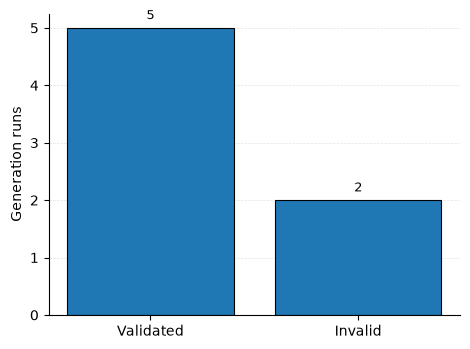

Saved: /home/mehedinaeem/Desktop/Code/ThetreStageAI/Notebooks/eda_outputs/figures/generation_run_validation_status.png
Saved: /home/mehedinaeem/Desktop/Code/ThetreStageAI/Notebooks/eda_outputs/figures/generation_run_validation_status.pdf


In [10]:
if not runs_df.empty:
    status_counts = pd.Series({
        "Validated": int(runs_df["validated"].sum()),
        "Invalid": int((~runs_df["validated"]).sum()),
    })

    fig, ax = plt.subplots(figsize=(4.8, 3.6))
    bars = ax.bar(
        status_counts.index,
        status_counts.values,
        edgecolor="black",
        linewidth=0.8,
    )

    ax.set_ylabel("Generation runs")
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.35)
    ax.set_axisbelow(True)

    for bar, value in zip(bars, status_counts.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            str(int(value)),
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()

    png_path = FIG_DIR / "generation_run_validation_status.png"
    pdf_path = FIG_DIR / "generation_run_validation_status.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print("Saved:", png_path)
    print("Saved:", pdf_path)
else:
    print("Skipped: no GenerationRun records.")


## 11. RAG-mode diagnostic summary

In [23]:
if not runs_df.empty:
    rag_summary = (
        runs_df.groupby("rag_mode", dropna=False)
        .agg(
            runs=("id", "count"),
            validated=("validated", "sum"),
            validation_rate=("validated", "mean"),
            median_generation_time_s=("generation_time_seconds", "median"),
            mean_repairs=("repair_attempts", "mean"),
        )
        .reset_index()
    )

    rag_summary["validation_rate"] = (100 * rag_summary["validation_rate"]).round(2)
    rag_summary["median_generation_time_s"] = rag_summary["median_generation_time_s"].round(2)
    rag_summary["mean_repairs"] = rag_summary["mean_repairs"].round(2)

    display(rag_summary)
    rag_summary.to_csv(TABLE_DIR / "rag_mode_diagnostic_summary.csv", index=False)
else:
    print("No runs available for RAG-mode summary.")


,rag_mode,runs,validated,validation_rate,median_generation_time_s,mean_repairs
0,full_multiview,4,4,100.0,30.55,0.0


## 12. Paper-use guidance

### Safe to report
- dataset record count;
- Scene/Blocking/Lighting retrieval counts;
- total retrieval-document count;
- dialogue/blocking/lighting/sound-cue counts;
- integrity checks and descriptive EDA.

### Do not report as final model performance without a controlled evaluation
- validation rate from mixed development runs;
- average generation time from different providers/settings;
- No-RAG vs RAG performance unless the same fixed prompt set is used;
- precision, recall, or F1 without a labeled evaluation protocol.

For a proper experimental Figure 7 later, compare the same test prompts across:

1. No RAG
2. Scene-only RAG
3. Combined/single RAG
4. Full multi-view RAG

using the same Gemini model, generation settings, and scoring criteria.
